In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


In [ ]:
# Upload the CSV file in Colab first

df = pd.read_csv("Unemployment in India.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("\nDataset Information:")
print(df.info())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   

In [ ]:
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500

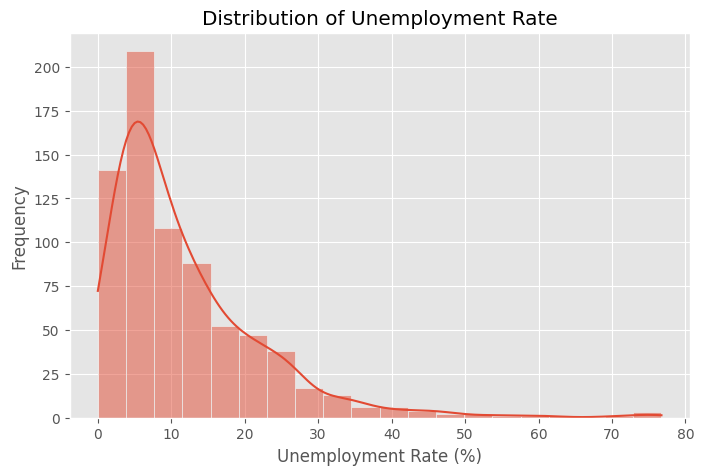

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

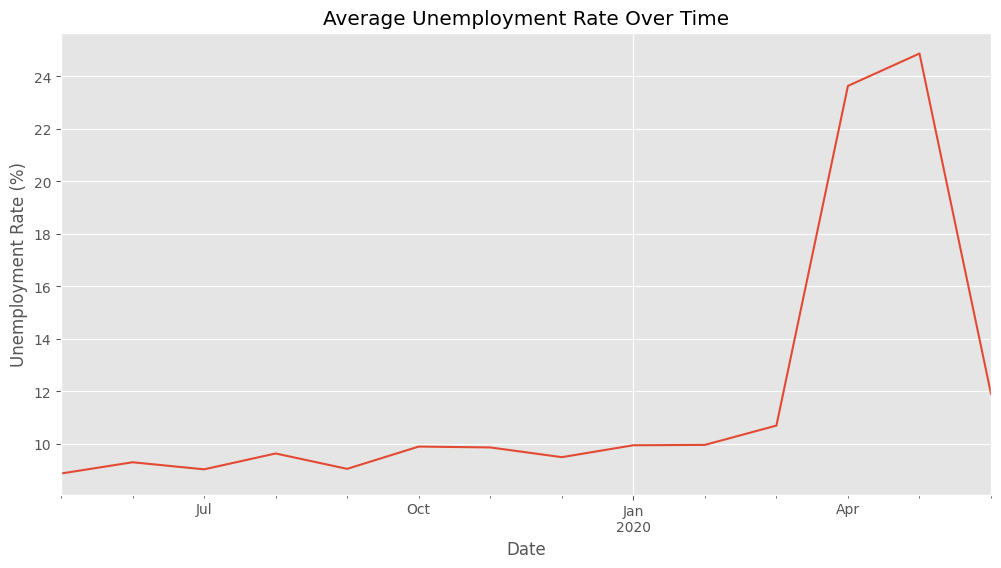

In [ ]:
monthly_trend = df.groupby('Date')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(12,6))
monthly_trend.plot()

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)

plt.show()

In [ ]:
pre_covid = df[df['Date'] < '2020-03-01']
during_covid = df[df['Date'] >= '2020-03-01']

print("Average Unemployment Before COVID:",
      round(pre_covid['Estimated Unemployment Rate (%)'].mean(),2))

print("Average Unemployment During COVID:",
      round(during_covid['Estimated Unemployment Rate (%)'].mean(),2))

Average Unemployment Before COVID: 9.51
Average Unemployment During COVID: 17.77


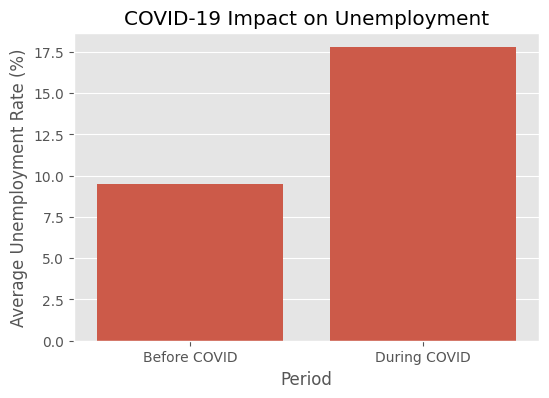

In [ ]:
covid_data = pd.DataFrame({
    'Period':['Before COVID','During COVID'],
    'Rate':[
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        during_covid['Estimated Unemployment Rate (%)'].mean()
    ]
})

plt.figure(figsize=(6,4))

sns.barplot(
    x='Period',
    y='Rate',
    data=covid_data
)

plt.title("COVID-19 Impact on Unemployment")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

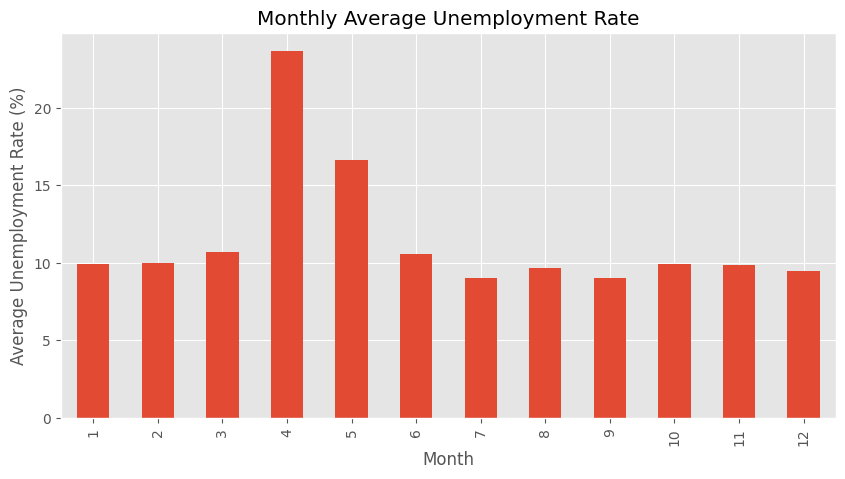

In [ ]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(10,5))

monthly_avg.plot(kind='bar')

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

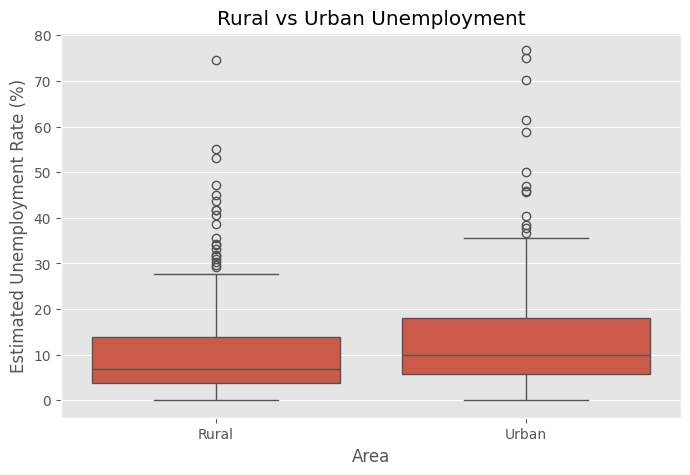

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Rural vs Urban Unemployment")
plt.show()

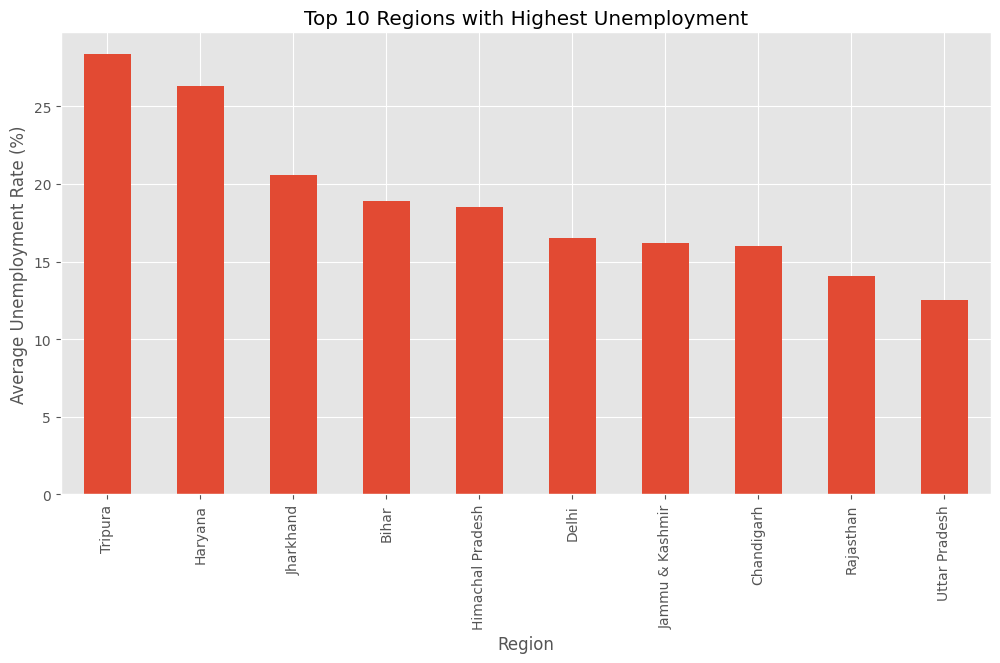

In [ ]:
state_avg = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

state_avg.head(10).plot(kind='bar')

plt.title("Top 10 Regions with Highest Unemployment")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

In [ ]:
print("PROJECT INSIGHTS")
print("- COVID-19 significantly increased unemployment rates.")
print("- April 2020 showed the highest unemployment levels.")
print("- Urban areas were more affected than rural areas.")
print("- Significant regional differences exist across India.")
print("- Unemployment trends vary seasonally and geographically.")

PROJECT INSIGHTS
- COVID-19 significantly increased unemployment rates.
- April 2020 showed the highest unemployment levels.
- Urban areas were more affected than rural areas.
- Significant regional differences exist across India.
- Unemployment trends vary seasonally and geographically.
